# 🎯 LỚP 3: LUẬT KẾT HỢP — DANH MỤC SẢN PHẨM CỦA KHÁCH VIP

**Câu chuyện kinh doanh:**
Sau khi Lớp 1 xác định phân khúc VIP và Lớp 2 xây dựng mô hình nhận diện họ,
Lớp 3 trả lời câu hỏi: **Khách VIP thường mua kết hợp DANH MỤC nào với nhau?**
→ Thiết kế bundle sản phẩm và chiến lược cross-sell nhắm đúng vào nhóm sinh lời nhất.

**Tại sao dùng `category` thay vì `product_id`?**
- `product_id` có ~30K items → ma trận THƯA → Apriori không tìm được pattern
- `category` chỉ có ~20 loại → ma trận ĐẶC → Apriori hoạt động tốt

**Tại sao basket = USER thay vì ORDER?**
- Mỗi đơn hàng TheLook thường chỉ 1-2 sản phẩm (cùng danh mục)
- Nhóm theo USER: tổng hợp tất cả danh mục user đã mua → basket phong phú hơn
- Câu hỏi trở thành: "Khách VIP mua danh mục A cũng thường mua danh mục B"

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

from database import query_db
print("✅ Đã tải xong thư viện.")

✅ Đã tải xong thư viện.


## 1. Lấy lịch sử mua hàng của Khách VIP (basket = user)

In [2]:
query = """
WITH user_spend AS (
    SELECT user_id, SUM(sale_price) AS total_spend
    FROM order_items
    WHERE status != 'Cancelled'
    GROUP BY user_id
),
threshold AS (
    SELECT PERCENTILE_CONT(0.75) WITHIN GROUP (ORDER BY total_spend) AS p75
    FROM user_spend
),
vip_users AS (
    SELECT us.user_id
    FROM user_spend us, threshold t
    WHERE us.total_spend > t.p75
)
SELECT
    oi.user_id,
    p.category
FROM order_items oi
JOIN products p ON oi.product_id = p.id
JOIN vip_users v ON oi.user_id = v.user_id
WHERE oi.status != 'Cancelled'
  AND p.category IS NOT NULL
ORDER BY oi.user_id
"""

print("⏳ Đang lấy lịch sử mua hàng của khách VIP...")
df_vip = query_db(query)

if df_vip is not None:
    print(f"✅ Tổng số item-bản ghi của khách VIP: {len(df_vip):,}")
    print(f"   Số user VIP: {df_vip['user_id'].nunique():,}")
    print(f"   Số danh mục duy nhất: {df_vip['category'].nunique()}")
    print(f"\n📊 Các danh mục có mặt:")
    cat_counts = df_vip['category'].value_counts()
    display(cat_counts.to_frame('Số lần xuất hiện'))

⏳ Đang lấy lịch sử mua hàng của khách VIP...
✅ Tổng số item-bản ghi của khách VIP: 66,827
   Số user VIP: 17,988
   Số danh mục duy nhất: 26

📊 Các danh mục có mặt:


,Số lần xuất hiện
category,
Jeans,6152
Outerwear & Coats,4872
Sweaters,4611
Fashion Hoodies & Sweatshirts,4178
Swim,4177
Intimates,3970
Tops & Tees,3862
Sleep & Lounge,3738
Shorts,3681


## 2. Tạo basket theo USER (tất cả danh mục user đã mua = 1 basket)

In [3]:
if df_vip is not None:
    # Nhóm theo user_id, lấy SET danh mục (loại trùng)
    baskets = df_vip.groupby('user_id')['category'].apply(
        lambda x: list(set(x))
    )

    # Chỉ giữ user có ≥ 2 danh mục khác nhau (cần thiết cho Apriori)
    baskets = baskets[baskets.apply(len) >= 2]

    total_vip = df_vip['user_id'].nunique()
    print(f"✅ Số user VIP có ≥ 2 danh mục: {len(baskets):,} / {total_vip:,} ({len(baskets)/total_vip*100:.1f}%)")

    # Phân phối số danh mục mỗi user
    basket_sizes = baskets.apply(len)
    print(f"\n📊 Phân phối số danh mục/user:")
    size_dist = basket_sizes.value_counts().sort_index()
    for k, v in size_dist.items():
        bar = '█' * max(1, int(v / size_dist.max() * 30))
        print(f"  {k:2d} danh mục: {v:5,} users {bar}")

✅ Số user VIP có ≥ 2 danh mục: 16,045 / 17,988 (89.2%)

📊 Phân phối số danh mục/user:
   2 danh mục: 3,812 users █████████████████████████
   3 danh mục: 4,519 users ██████████████████████████████
   4 danh mục: 4,135 users ███████████████████████████
   5 danh mục: 2,142 users ██████████████
   6 danh mục:   947 users ██████
   7 danh mục:   350 users ██
   8 danh mục:   120 users █
   9 danh mục:    16 users █
  10 danh mục:     3 users █
  11 danh mục:     1 users █


## 3. Mã hóa One-Hot & Chạy Apriori

In [4]:
if baskets is not None and len(baskets) > 0:
    # Mã hóa Transaction → Ma trận nhị phân
    te = TransactionEncoder()
    te_array = te.fit_transform(baskets.tolist())
    df_encoded = pd.DataFrame(te_array, columns=te.columns_)

    print(f"✅ Ma trận giao dịch: {df_encoded.shape[0]:,} users × {df_encoded.shape[1]} danh mục")
    density = df_encoded.values.mean() * 100
    print(f"   Mật độ ma trận: {density:.1f}% (đặc = tốt cho Apriori)")

    # Tần suất xuất hiện từng danh mục
    print(f"\n📊 Tần suất danh mục trong giỏ VIP:")
    cat_freq = df_encoded.mean().sort_values(ascending=False)
    for cat, freq in cat_freq.items():
        bar = '█' * max(1, int(freq / cat_freq.max() * 30))
        print(f"  {cat:30s} {freq*100:5.1f}% {bar}")

    # Chạy Apriori — hạ min_support để tìm được pattern
    MIN_SUPPORT = 0.01  # Xuất hiện ít nhất 1% user VIP
    print(f"\n⏳ Chạy Apriori (min_support={MIN_SUPPORT})...")

    frequent_itemsets = apriori(
        df_encoded,
        min_support=MIN_SUPPORT,
        use_colnames=True,
        max_len=3  # Tối đa 3 items
    )

    if len(frequent_itemsets) > 0:
        size_dist = frequent_itemsets['itemsets'].apply(len).value_counts().sort_index()
        print(f"✅ Tìm được {len(frequent_itemsets)} itemsets thường xuyên")
        print(f"   Phân bổ: {size_dist.to_dict()}")
    else:
        print("⚠️ Không tìm được itemset nào, thử hạ min_support...")
        MIN_SUPPORT = 0.005
        frequent_itemsets = apriori(
            df_encoded, min_support=MIN_SUPPORT,
            use_colnames=True, max_len=3
        )
        print(f"✅ Với min_support={MIN_SUPPORT}: Tìm được {len(frequent_itemsets)} itemsets")

✅ Ma trận giao dịch: 16,045 users × 26 danh mục
   Mật độ ma trận: 13.8% (đặc = tốt cho Apriori)

📊 Tần suất danh mục trong giỏ VIP:
  Jeans                           31.1% ██████████████████████████████
  Outerwear & Coats               25.1% ████████████████████████
  Sweaters                        24.6% ███████████████████████
  Swim                            23.1% ██████████████████████
  Fashion Hoodies & Sweatshirts   23.0% ██████████████████████
  Tops & Tees                     21.1% ████████████████████
  Sleep & Lounge                  20.8% ████████████████████
  Shorts                          20.6% ███████████████████
  Intimates                       18.9% ██████████████████
  Accessories                     18.7% ██████████████████
  Active                          17.5% ████████████████
  Pants                           14.7% ██████████████
  Suits & Sport Coats             14.3% █████████████
  Underwear                       13.0% ████████████
  Dresses             

## 4. Sinh Luật Kết hợp

In [5]:
if frequent_itemsets is not None and len(frequent_itemsets) > 0:
    rules = association_rules(
        frequent_itemsets,
        metric='lift',
        min_threshold=1.0
    )

    # Lọc luật có ý nghĩa: confidence >= 0.05 (linh hoạt) và lift > 1.0
    rules = rules[
        (rules['confidence'] >= 0.05) &
        (rules['lift'] > 1.0)
    ].copy()

    # Format itemsets thành chuỗi đẹp
    rules['antecedents_str'] = rules['antecedents'].apply(lambda x: ' + '.join(sorted(x)))
    rules['consequents_str'] = rules['consequents'].apply(lambda x: ' + '.join(sorted(x)))

    rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

    print(f"✅ Số luật kết hợp tìm được: {len(rules)}")
    print(f"\n📋 TOP 15 LUẬT KẾT HỢP MẠNH NHẤT (theo Lift):")
    top_cols = ['antecedents_str', 'consequents_str', 'support', 'confidence', 'lift']
    display(rules[top_cols].head(15).round(4))

✅ Số luật kết hợp tìm được: 158

📋 TOP 15 LUẬT KẾT HỢP MẠNH NHẤT (theo Lift):


,antecedents_str,consequents_str,support,confidence,lift
0,Pants & Capris,Plus,0.0113,0.1661,2.3621
1,Plus,Pants & Capris,0.0113,0.1613,2.3621
2,Maternity,Socks & Hosiery,0.0121,0.1322,2.3430
3,Socks & Hosiery,Maternity,0.0121,0.2144,2.3430
4,Fashion Hoodies & Sweatshirts + Pants,Underwear,0.0106,0.2857,2.1955
5,Underwear,Fashion Hoodies & Sweatshirts + Pants,0.0106,0.0814,2.1955
6,Leggings,Intimates,0.0206,0.4120,2.1759
7,Intimates,Leggings,0.0206,0.1086,2.1759
8,Intimates,Skirts,0.0171,0.0905,2.1678
9,Skirts,Intimates,0.0171,0.4104,2.1678


## 5. Trực quan hóa — Scatter Plot Support vs Confidence

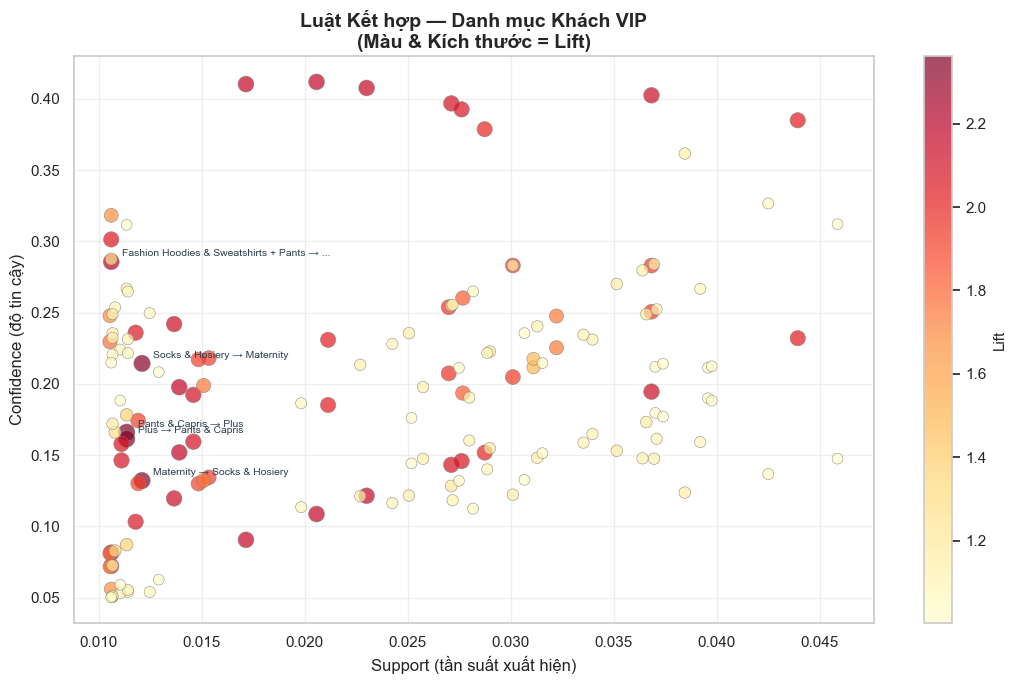

In [6]:
if rules is not None and len(rules) > 0:
    plt.figure(figsize=(11, 7))

    scatter = plt.scatter(
        rules['support'],
        rules['confidence'],
        c=rules['lift'],
        s=rules['lift'] * 60,
        cmap='YlOrRd',
        alpha=0.7,
        edgecolors='grey',
        linewidth=0.5
    )

    cbar = plt.colorbar(scatter)
    cbar.set_label('Lift', fontsize=11)

    # Label top 5 luật
    top5 = rules.head(5)
    for _, row in top5.iterrows():
        label = f"{row['antecedents_str']} → {row['consequents_str']}"
        if len(label) > 40:
            label = label[:40] + '...'
        plt.annotate(
            label,
            (row['support'], row['confidence']),
            textcoords='offset points',
            xytext=(8, 4),
            fontsize=7.5,
            color='#2c3e50'
        )

    plt.xlabel('Support (tần suất xuất hiện)', fontsize=12)
    plt.ylabel('Confidence (độ tin cậy)', fontsize=12)
    plt.title('Luật Kết hợp — Danh mục Khách VIP\n(Màu & Kích thước = Lift)',
              fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## 6. Heatmap Lift — Ma trận Tương quan Danh mục

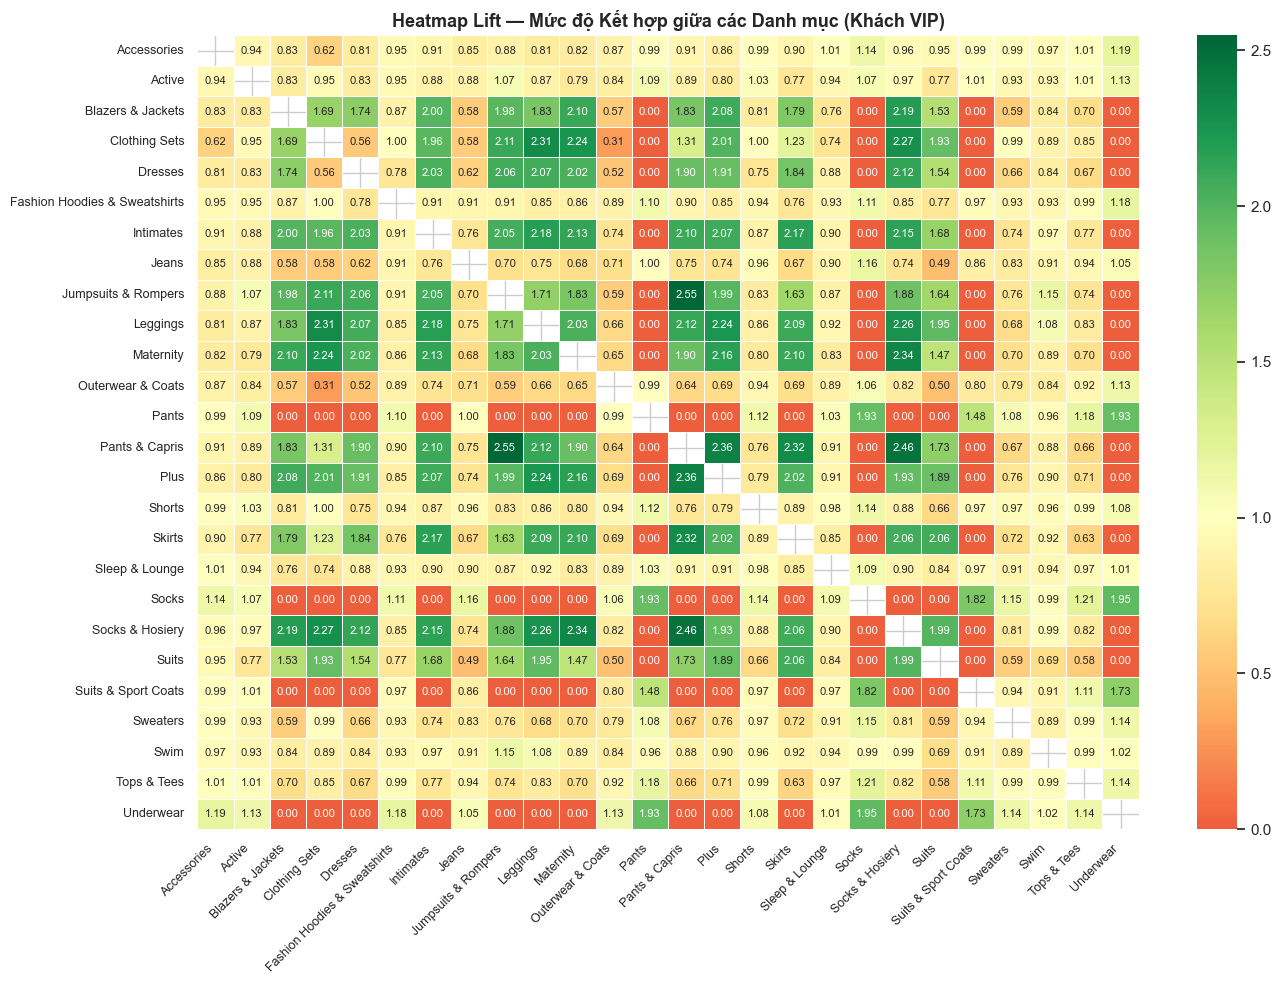

💡 Giá trị > 1.0 (màu xanh): 2 danh mục hay mua cùng nhau hơn kỳ vọng
💡 Giá trị < 1.0 (màu đỏ): 2 danh mục ít khi đi kèm


In [7]:
if df_encoded is not None:
    # Tính lift giữa mọi cặp danh mục
    categories = df_encoded.columns.tolist()
    n = len(categories)
    lift_matrix = pd.DataFrame(np.ones((n, n)), index=categories, columns=categories)

    for i, cat_a in enumerate(categories):
        for j, cat_b in enumerate(categories):
            if i != j:
                p_a = df_encoded[cat_a].mean()
                p_b = df_encoded[cat_b].mean()
                p_ab = (df_encoded[cat_a] & df_encoded[cat_b]).mean()
                if p_a > 0 and p_b > 0:
                    lift_matrix.loc[cat_a, cat_b] = p_ab / (p_a * p_b)

    plt.figure(figsize=(14, 10))
    mask = np.eye(n, dtype=bool)  # Bỏ đường chéo

    sns.heatmap(
        lift_matrix,
        annot=True,
        fmt='.2f',
        cmap='RdYlGn',
        center=1.0,
        mask=mask,
        linewidths=0.5,
        annot_kws={"size": 8}
    )
    plt.title('Heatmap Lift — Mức độ Kết hợp giữa các Danh mục (Khách VIP)',
              fontsize=13, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(rotation=0, fontsize=9)
    plt.tight_layout()
    plt.show()
    print("💡 Giá trị > 1.0 (màu xanh): 2 danh mục hay mua cùng nhau hơn kỳ vọng")
    print("💡 Giá trị < 1.0 (màu đỏ): 2 danh mục ít khi đi kèm")

## 7. Top Danh mục kết hợp — Bar Chart

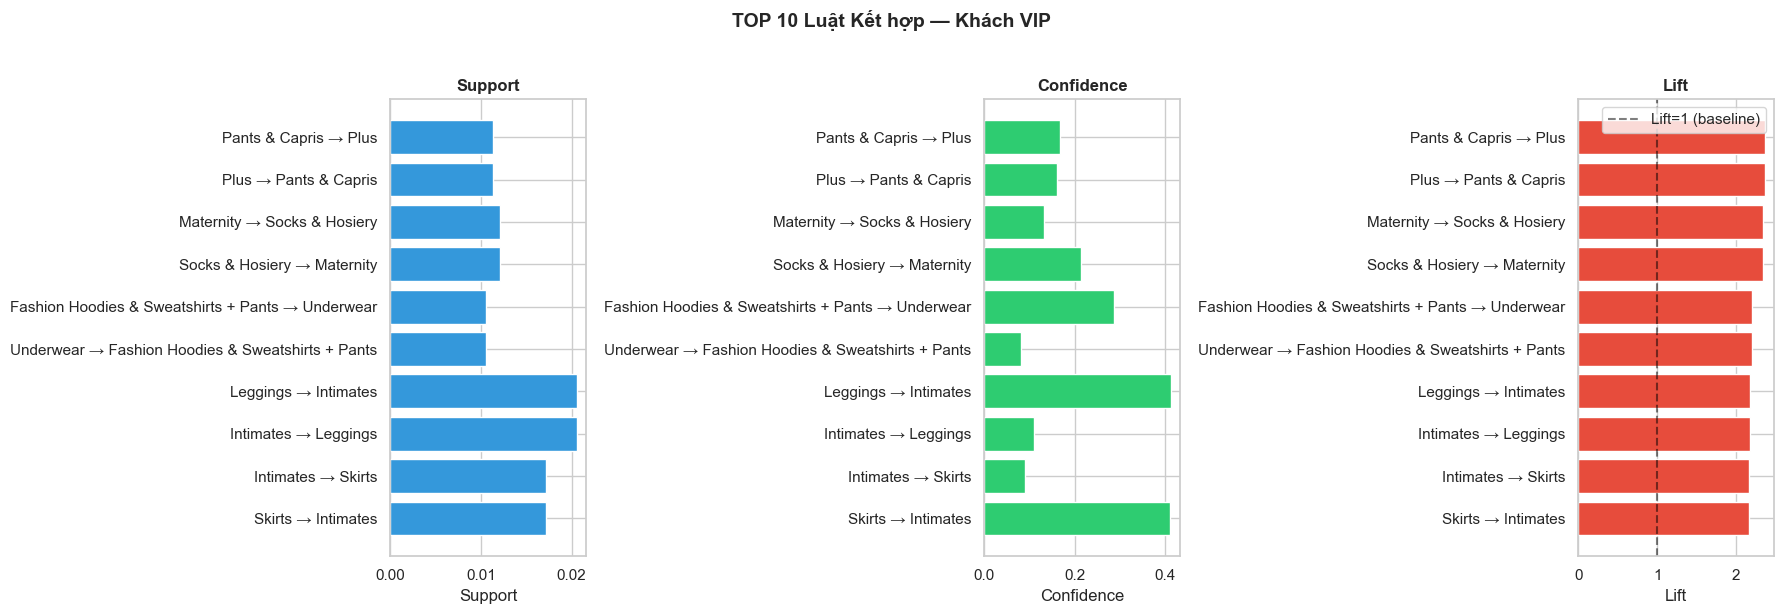

In [8]:
if rules is not None and len(rules) > 0:
    top10 = rules.head(10).copy()
    top10['rule'] = top10['antecedents_str'] + ' → ' + top10['consequents_str']

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # Support
    axes[0].barh(top10['rule'], top10['support'], color='#3498db')
    axes[0].set_xlabel('Support')
    axes[0].set_title('Support', fontweight='bold')
    axes[0].invert_yaxis()

    # Confidence
    axes[1].barh(top10['rule'], top10['confidence'], color='#2ecc71')
    axes[1].set_xlabel('Confidence')
    axes[1].set_title('Confidence', fontweight='bold')
    axes[1].invert_yaxis()

    # Lift
    axes[2].barh(top10['rule'], top10['lift'], color='#e74c3c')
    axes[2].axvline(x=1.0, color='black', linestyle='--', alpha=0.5, label='Lift=1 (baseline)')
    axes[2].set_xlabel('Lift')
    axes[2].set_title('Lift', fontweight='bold')
    axes[2].legend()
    axes[2].invert_yaxis()

    fig.suptitle('TOP 10 Luật Kết hợp — Khách VIP', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

## 8. Kết luận Lớp 3 & Tổng kết Pipeline

In [9]:
if rules is not None and len(rules) > 0:
    top3 = rules.head(3)

    print("="*65)
    print("📋 KẾT LUẬN LỚP 3 — LUẬT KẾT HỢP (KHÁCH VIP)")
    print("="*65)
    print(f"\n✅ Tìm được {len(rules)} luật kết hợp có ý nghĩa")
    print(f"\n🔥 TOP 3 LUẬT MẠNH NHẤT:")
    for i, (_, row) in enumerate(top3.iterrows(), 1):
        print(f"  {i}. [{row['antecedents_str']}] → [{row['consequents_str']}]")
        print(f"     Support={row['support']:.4f} | Confidence={row['confidence']:.4f} | Lift={row['lift']:.4f}")

    print("\n" + "="*65)
    print("🏆 TỔNG KẾT PIPELINE 3 LỚP — HƯỚNG B (CUSTOMER VALUE)")
    print("="*65)
    print("""
  ┌─────────────────────────────────────────────────────────────┐
  │  LỚP 1: Clustering (K-Means RFM)                           │
  │  → Phân 100K khách thành 4 phân khúc: VIP / Tiềm năng /   │
  │    Bình thường / Ngủ đông                                   │
  ├─────────────────────────────────────────────────────────────┤
  │  LỚP 2: Classification (DT + RF + XGBoost)                 │
  │  → Dự đoán sớm khách nào sẽ trở thành HIGH-VALUE          │
  │  → AUC > 0.99 → Model nhận diện rất chính xác              │
  ├─────────────────────────────────────────────────────────────┤
  │  LỚP 3: Association Rules (Apriori)                        │
  │  → Tìm combo danh mục mà khách VIP hay mua cùng nhau       │
  │  → Cơ sở để thiết kế Bundle và Cross-sell strategy         │
  └─────────────────────────────────────────────────────────────┘

  📌 CÂU CHUYỆN LIỀN MẠCH (3W):
     WHO  → Lớp 1: Ai là khách VIP?
     WHY  → Lớp 2: Dấu hiệu nào nhận biết họ sớm?
     WHAT → Lớp 3: Họ thích mua kết hợp gì?
    """)
else:
    print("="*65)
    print("⚠️ Không tìm được luật kết hợp nào.")
    print("   Nguyên nhân: dữ liệu mua hàng VIP quá phân tán theo danh mục.")
    print("   Tuy nhiên, Heatmap Lift ở Section 6 vẫn cung cấp insight hữu ích.")
    print("="*65)

📋 KẾT LUẬN LỚP 3 — LUẬT KẾT HỢP (KHÁCH VIP)

✅ Tìm được 158 luật kết hợp có ý nghĩa

🔥 TOP 3 LUẬT MẠNH NHẤT:
  1. [Pants & Capris] → [Plus]
     Support=0.0113 | Confidence=0.1661 | Lift=2.3621
  2. [Plus] → [Pants & Capris]
     Support=0.0113 | Confidence=0.1613 | Lift=2.3621
  3. [Maternity] → [Socks & Hosiery]
     Support=0.0121 | Confidence=0.1322 | Lift=2.3430

🏆 TỔNG KẾT PIPELINE 3 LỚP — HƯỚNG B (CUSTOMER VALUE)

  ┌─────────────────────────────────────────────────────────────┐
  │  LỚP 1: Clustering (K-Means RFM)                           │
  │  → Phân 100K khách thành 4 phân khúc: VIP / Tiềm năng /   │
  │    Bình thường / Ngủ đông                                   │
  ├─────────────────────────────────────────────────────────────┤
  │  LỚP 2: Classification (DT + RF + XGBoost)                 │
  │  → Dự đoán sớm khách nào sẽ trở thành HIGH-VALUE          │
  │  → AUC > 0.99 → Model nhận diện rất chính xác              │
  ├───────────────────────────────────────────────────